# LeetCode #33: Search in Rotated Sorted Array

https://leetcode.com/problems/search-in-rotated-sorted-array/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (linear scan)** | $O(n)$ | $O(1)$ |
| **Optimal: Binary Search with Pivot Detection ★** | $O(\log n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (linear scan)
Scan every element until the target is found. Correct but $O(n)$ — wastes the sorted structure entirely.

### Optimal: Binary Search with Pivot Detection ★
At any `mid`, one of the two halves must be fully sorted. Compare `nums[lo]` with `nums[mid]` to identify the sorted half; if the target lies in that sorted range, narrow to it, otherwise narrow to the other half. Each step halves the search space despite the rotation.

**Constraints:**
* 1 <= nums.length <= 5000
* -10^4 <= nums[i] <= 10^4
* All values of nums are unique
* nums is an ascending array that is possibly rotated
* -10^4 <= target <= 10^4


## Solutions

### C#

In [ ]:
public int Search(int[] nums, int target) {
    int lo = 0, hi = nums.Length - 1;
    while (lo <= hi) {
        int mid = lo + (hi - lo) / 2;
        if (nums[mid] == target) return mid;
        // Determine which half is fully sorted
        if (nums[lo] <= nums[mid]) {
            // Left half is sorted; check if target belongs there
            if (nums[lo] <= target && target < nums[mid]) hi = mid - 1;
            else lo = mid + 1;
        } else {
            // Right half is sorted; check if target belongs there
            if (nums[mid] < target && target <= nums[hi]) lo = mid + 1;
            else hi = mid - 1;
        }
    }
    return -1;
}


### Python

In [ ]:
def search(self, nums: list[int], target: int) -> int:
    lo, hi = 0, len(nums) - 1
    while lo <= hi:
        mid = lo + (hi - lo) // 2
        if nums[mid] == target:
            return mid
        # Determine which half is fully sorted
        if nums[lo] <= nums[mid]:
            # Left half is sorted; check if target belongs there
            if nums[lo] <= target < nums[mid]:
                hi = mid - 1
            else:
                lo = mid + 1
        else:
            # Right half is sorted; check if target belongs there
            if nums[mid] < target <= nums[hi]:
                lo = mid + 1
            else:
                hi = mid - 1
    return -1


### Go

In [ ]:
func search(nums []int, target int) int {
    lo, hi := 0, len(nums)-1
    for lo <= hi {
        mid := lo + (hi-lo)/2
        if nums[mid] == target {
            return mid
        }
        // Determine which half is fully sorted
        if nums[lo] <= nums[mid] {
            // Left half is sorted; check if target belongs there
            if nums[lo] <= target && target < nums[mid] {
                hi = mid - 1
            } else {
                lo = mid + 1
            }
        } else {
            // Right half is sorted; check if target belongs there
            if nums[mid] < target && target <= nums[hi] {
                lo = mid + 1
            } else {
                hi = mid - 1
            }
        }
    }
    return -1
}


### Rust

In [ ]:
pub fn search(nums: Vec<i32>, target: i32) -> i32 {
    let (mut lo, mut hi) = (0i32, nums.len() as i32 - 1);
    while lo <= hi {
        let mid = lo + (hi - lo) / 2;
        if nums[mid as usize] == target { return mid; }
        // Determine which half is fully sorted
        if nums[lo as usize] <= nums[mid as usize] {
            // Left half is sorted; check if target belongs there
            if nums[lo as usize] <= target && target < nums[mid as usize] {
                hi = mid - 1;
            } else {
                lo = mid + 1;
            }
        } else {
            // Right half is sorted; check if target belongs there
            if nums[mid as usize] < target && target <= nums[hi as usize] {
                lo = mid + 1;
            } else {
                hi = mid - 1;
            }
        }
    }
    -1
}


## Example Scenarios

**1. Common Case**
**Input:** nums = [4, 5, 6, 7, 0, 1, 2], target = 0
mid=3, nums[3]=7; left half [4..7] sorted, 0 not in [4,7) → lo=4. mid=5, nums[5]=1; right half [0..2] sorted, 0 in (1,2]? No → hi=4. mid=4, nums[4]=0 → return 4.

**2. Slightly Complex**
**Input:** nums = [4, 5, 6, 7, 0, 1, 2], target = 3
Every branch eliminates half the array; target 3 never matches any pivot boundary, so lo eventually exceeds hi. Returns -1 after $O(\log 7) \approx 3$ iterations.

**3. Edge Case: Time Factor**
**Input:** nums = [1, 3], target = 3
Single iteration: mid=0, nums[0]=1; left sorted, 3 not in [1,3) → lo=1. Second iteration: mid=1, nums[1]=3 → return 1. Worst-case depth $\lceil \log_2 n \rceil$.

**4. Edge Case: Space Factor**
**Input:** nums = [1], target = 0
Space is $O(1)$ — only three pointers (lo, hi, mid) regardless of input size. Here lo=hi=0, nums[0]=1 ≠ 0, left sorted, 0 not in [1,1) → lo=1 > hi → return -1.

**5. Almost-Impossible but Plausible**
**Input:** nums = [-10000, 9999, -9999], target = -9999
Rotation places -9999 at index 2. mid=1, nums[1]=9999; nums[lo]=nums[0]=-10000 ≤ 9999 so left sorted; target -9999 not in [-10000, 9999) → lo=2. mid=2, nums[2]=-9999 → return 2. Extreme boundary values confirm pivot logic handles negative+positive mix.


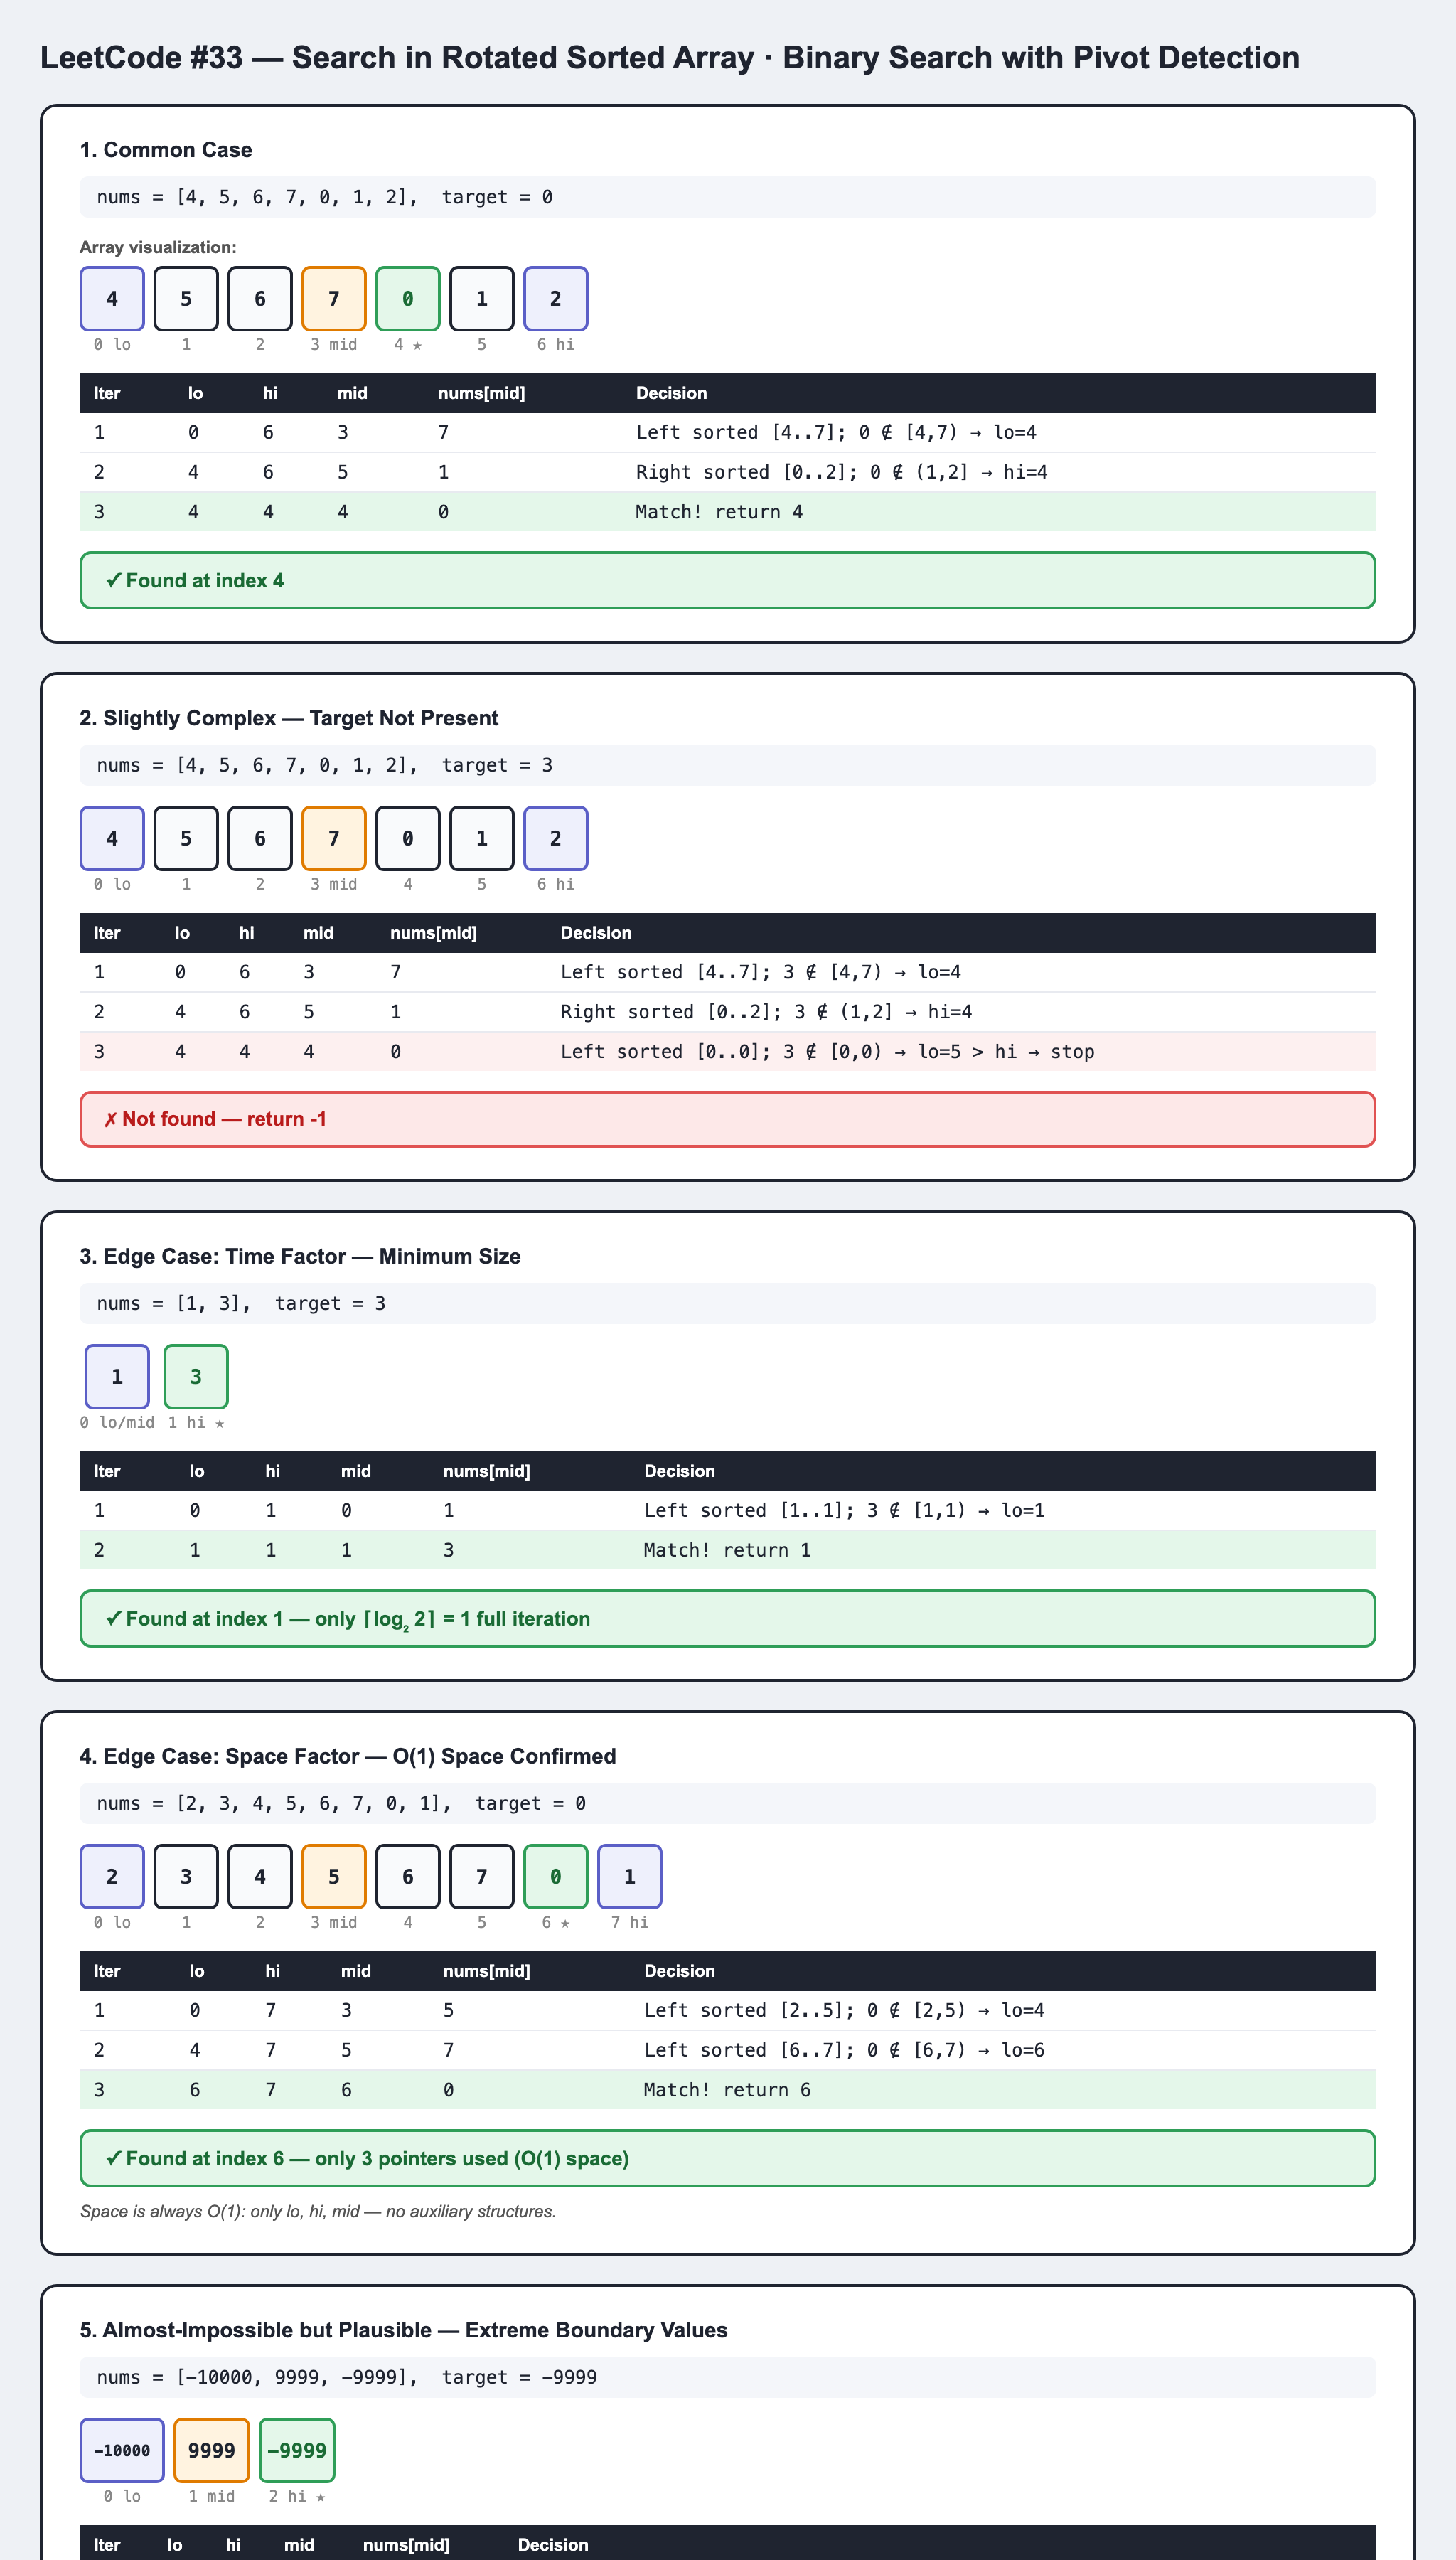